# Phase 2 — Lag analysis (CCF)

For each of DE, GB, RU, we compute the cross-correlation function (CCF) between monthly arrivals and (a) the market's Google-Trends keyword and (b) the corresponding real exchange rate, over lags **-6 to +6 months**.

_Sign convention used throughout:_ a **positive lag k** means the regressor leads arrivals by k months — that is, $\rho(k) = \text{corr}(x_{t-k}, y_t)$, so the regressor's value k months ago is correlated with arrivals today. A **negative lag** means the regressor lags arrivals.

**Caveat — raw-series CCF.** Tourism arrivals are dominated by a strong annual seasonal cycle; Google-Trends search intent has the same seasonal shape. The CCF on the raw series will largely reflect this shared seasonality, which biases the peak-correlation lag toward 0. Treat the headline numbers as a first pass; a YoY-percent or seasonally-differenced CCF (12-month difference) is a sensible follow-up if a sharper lead/lag estimate is needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

ROOT = Path('..').resolve()
FIG_DIR = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_csv(ROOT / 'data' / 'processed' / 'master_monthly.csv',
                 index_col=0, parse_dates=True)
df.index.name = 'date'

MARKETS = {
    'DE': {'trends': 'trends_DE_Türkei_Urlaub',  'real_fx': 'real_EUR_TRY', 'color': '#1f4e79'},
    'GB': {'trends': 'trends_GB_Turkey_holiday', 'real_fx': 'real_GBP_TRY', 'color': '#2e7d32'},
    'RU': {'trends': 'trends_RU_Турция_отдых',   'real_fx': 'real_RUB_TRY', 'color': '#7e57c2'},
}
MAX_LAG = 6

## Cross-correlation helper

`ccf_two_sided` computes Pearson correlation between $x_{t-k}$ and $y_t$ for $k = -L, \ldots, +L$. Inputs are aligned to their overlapping period and NaNs are dropped pairwise. The asymptotic 95% white-noise band at each lag is $\pm 1.96 / \sqrt{N_{\text{eff}}(k)}$ where $N_{\text{eff}}(k) = N - |k|$ is the number of usable observations at that lag.

In [2]:
def ccf_two_sided(x: pd.Series, y: pd.Series, max_lag: int = MAX_LAG):
    """Return (lags, ccf_values, conf_band, n_overlap).
    
    Positive lag k: x leads y by k months (corr of x_{t-k} with y_t).
    Negative lag k: x lags y by |k| months.
    """
    pair = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    n = len(pair)
    xv = (pair['x'] - pair['x'].mean()) / pair['x'].std()
    yv = (pair['y'] - pair['y'].mean()) / pair['y'].std()
    
    lags = np.arange(-max_lag, max_lag + 1)
    vals = np.full(len(lags), np.nan)
    for i, k in enumerate(lags):
        if k >= 0:
            a = xv.iloc[:n - k].values
            b = yv.iloc[k:].values
        else:
            a = xv.iloc[-k:].values
            b = yv.iloc[:n + k].values
        if len(a) > 2:
            vals[i] = np.corrcoef(a, b)[0, 1]
    
    conf = 1.96 / np.sqrt(np.maximum(n - np.abs(lags), 1))
    return lags, vals, conf, n


def plot_ccf(ax, lags, vals, conf, n, title, color):
    ax.bar(lags, vals, color=color, alpha=0.85, edgecolor='white')
    ax.plot(lags, conf, color='#cc4c4c', ls='--', lw=1, label='95% band')
    ax.plot(lags, -conf, color='#cc4c4c', ls='--', lw=1)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Lag k (months)  — k>0: x leads arrivals')
    ax.set_ylabel('Correlation')
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(f'{title}  (N={n})')
    ax.legend(loc='lower left', fontsize=9, framealpha=0.95)

## DE

CCF of `trends_DE_Türkei_Urlaub` and `real_EUR_TRY` versus `arrivals_total`.

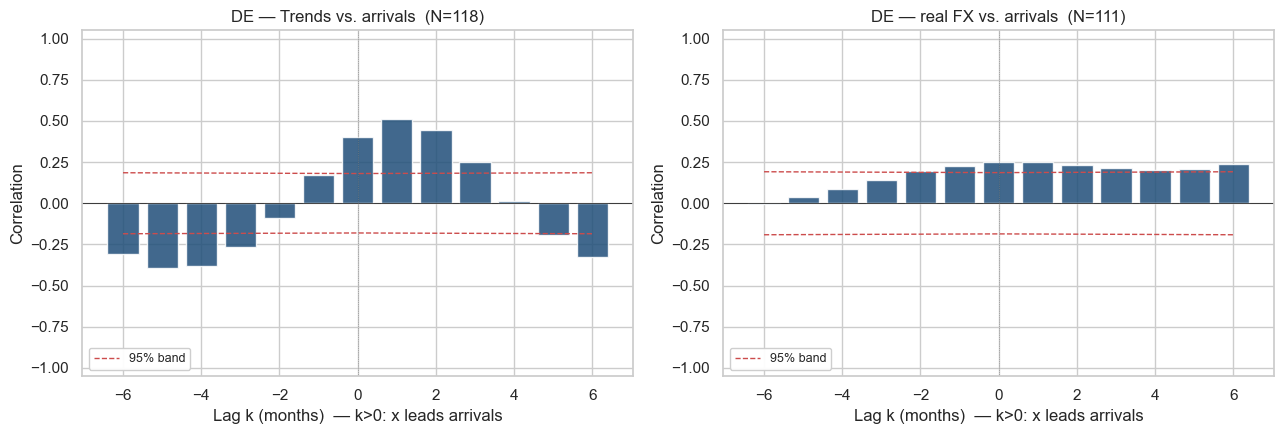

In [3]:
mkt = 'DE'
spec = MARKETS[mkt]

lags_t, vals_t, conf_t, n_t = ccf_two_sided(df[spec['trends']],  df['arrivals_total'])
lags_f, vals_f, conf_f, n_f = ccf_two_sided(df[spec['real_fx']], df['arrivals_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_ccf(axes[0], lags_t, vals_t, conf_t, n_t,
         f'{mkt} — Trends vs. arrivals', spec['color'])
plot_ccf(axes[1], lags_f, vals_f, conf_f, n_f,
         f'{mkt} — real FX vs. arrivals', spec['color'])
fig.tight_layout()
fig.savefig(FIG_DIR / f'lag_{mkt}_ccf.png', dpi=150)
plt.show()

## GB

CCF of `trends_GB_Turkey_holiday` and `real_GBP_TRY` versus `arrivals_total`.

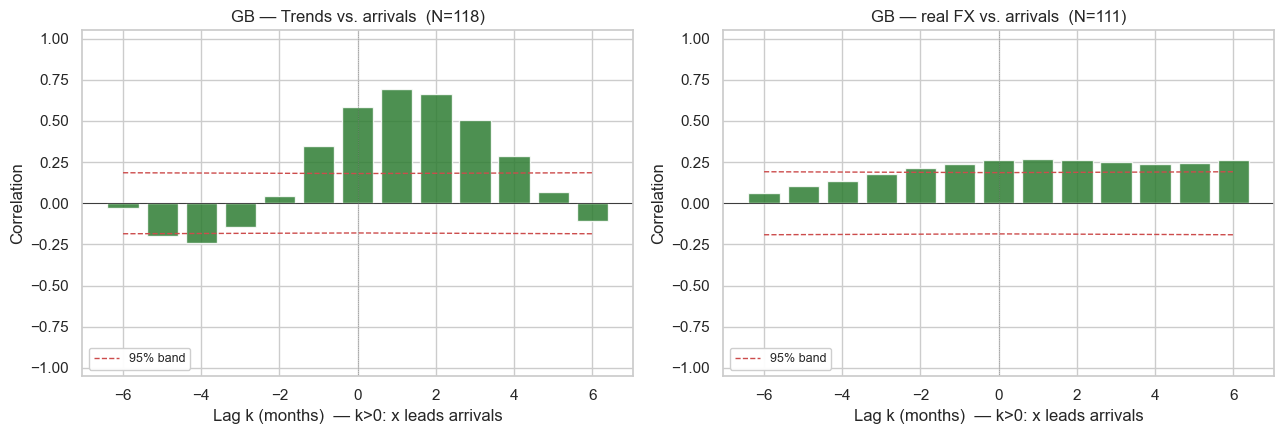

In [4]:
mkt = 'GB'
spec = MARKETS[mkt]

lags_t, vals_t, conf_t, n_t = ccf_two_sided(df[spec['trends']],  df['arrivals_total'])
lags_f, vals_f, conf_f, n_f = ccf_two_sided(df[spec['real_fx']], df['arrivals_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_ccf(axes[0], lags_t, vals_t, conf_t, n_t,
         f'{mkt} — Trends vs. arrivals', spec['color'])
plot_ccf(axes[1], lags_f, vals_f, conf_f, n_f,
         f'{mkt} — real FX vs. arrivals', spec['color'])
fig.tight_layout()
fig.savefig(FIG_DIR / f'lag_{mkt}_ccf.png', dpi=150)
plt.show()

## RU

CCF of `trends_RU_Турция_отдых` and `real_RUB_TRY` versus `arrivals_total`.

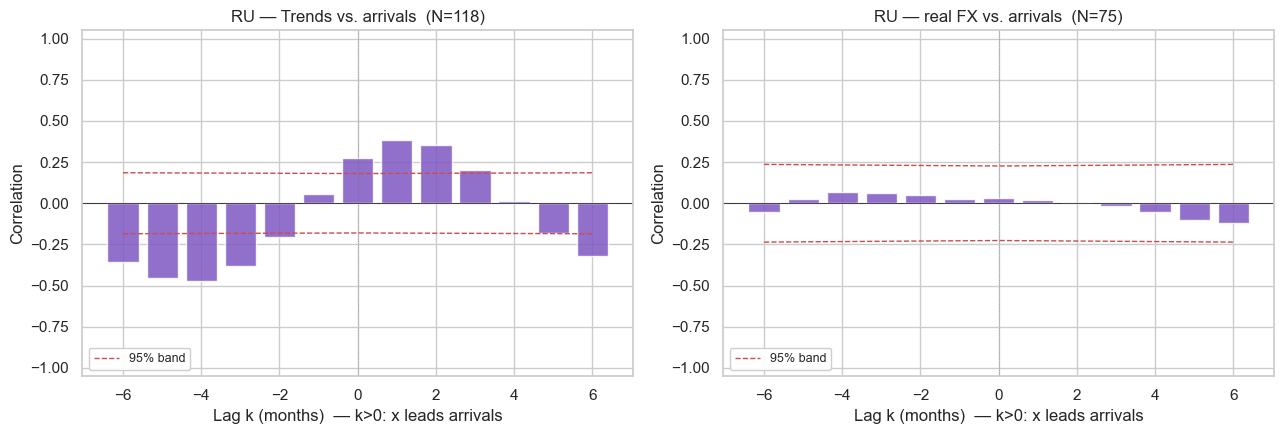

In [5]:
mkt = 'RU'
spec = MARKETS[mkt]

lags_t, vals_t, conf_t, n_t = ccf_two_sided(df[spec['trends']],  df['arrivals_total'])
lags_f, vals_f, conf_f, n_f = ccf_two_sided(df[spec['real_fx']], df['arrivals_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_ccf(axes[0], lags_t, vals_t, conf_t, n_t,
         f'{mkt} — Trends vs. arrivals', spec['color'])
plot_ccf(axes[1], lags_f, vals_f, conf_f, n_f,
         f'{mkt} — real FX vs. arrivals', spec['color'])
fig.tight_layout()
fig.savefig(FIG_DIR / f'lag_{mkt}_ccf.png', dpi=150)
plt.show()

## Summary — lag of peak correlation

For each (market, regressor) pair: the lag $k^*$ at which $|\rho(k)|$ is maximised, the value $\rho(k^*)$, the 95% band edge at $k^*$, and whether the peak is statistically distinct from white noise.

Re-read the seasonality caveat at the top before drawing inferences from the lag column — peaks at $k = 0$ on the Trends rows are almost certainly the shared seasonal cycle, not a true contemporaneous causal link.

In [6]:
rows = []
for mkt, spec in MARKETS.items():
    for kind, col in [('Trends', spec['trends']), ('real FX', spec['real_fx'])]:
        lags, vals, conf, n = ccf_two_sided(df[col], df['arrivals_total'])
        absvals = np.abs(vals)
        if np.all(np.isnan(absvals)):
            continue
        i = int(np.nanargmax(absvals))
        rows.append({
            'market':    mkt,
            'regressor': kind,
            'column':    col,
            'n_overlap': n,
            'peak_lag':  int(lags[i]),
            'rho_peak':  round(float(vals[i]), 3),
            'conf_95':   round(float(conf[i]), 3),
            'significant': bool(abs(vals[i]) > conf[i]),
        })
summary = pd.DataFrame(rows)
summary

,market,regressor,column,n_overlap,peak_lag,rho_peak,conf_95,significant
0,DE,Trends,trends_DE_Türkei_Urlaub,118,1,0.509,0.181,True
1,DE,real FX,real_EUR_TRY,111,0,0.253,0.186,True
2,GB,Trends,trends_GB_Turkey_holiday,118,1,0.691,0.181,True
3,GB,real FX,real_GBP_TRY,111,1,0.270,0.187,True
4,RU,Trends,trends_RU_Турция_отдых,118,-4,-0.472,0.184,True
5,RU,real FX,real_RUB_TRY,75,6,-0.123,0.236,False


In [7]:
summary.to_csv(ROOT / 'outputs' / 'lag_summary.csv', index=False)
print(f"→ outputs/lag_summary.csv")

→ outputs/lag_summary.csv


## Next

If the peak-lag values look mostly seasonality-driven (typical signature: every Trends row peaks at $k=0$ with $\rho > 0.8$), the natural next step before modelling is to rebuild the CCF on **year-over-year percent change** or **seasonal first difference** ($\Delta_{12}$). That removes the shared cycle and isolates the lead/lag in the *deviation* from each series' typical monthly path.